# Individual Homework 6 (Multi-Agent Systems)
## Matúš Halák : 2724858

### Monte Carlo Tree Search
- left: 0, right: 1
- max depth, d: 20
- root node's adress: None
- eg. depth 3 LRR node's adress: 011

In [85]:
import numpy as np

def edit_dist(A_i:np.ndarray, A_t:np.ndarray)->int:
    return (A_i != A_t).sum()

def leaf_reward(leaf:np.ndarray, target:np.ndarray, 
                B:float, tau:float):
    # edit distance of node - target
    dist_leaf = edit_dist(leaf, target)
    # unique epsilon per leaf node (fixed seed based on binary value)
    binary_value = int("".join(leaf.astype(str)), 2)
    rng = np.random.default_rng(binary_value) # local deterministic RNG
    eps_leaf = rng.standard_normal()
    
    return (B * np.exp(-dist_leaf / tau)) + eps_leaf

In [158]:
class Node:
    # Class-level constants
    # max tree depth
    DMAX = 20
    # adress of target node
    seed = np.random.seed(2025)
    At = np.random.randint(0,2, DMAX)
    # Leaf reward params
    B = 10
    tau = DMAX/5
    # number of random rollouts to estimate node values 
    nrollout = 3

    def __init__(self,
                 action = None,
                 parent = None):
        self.state_visits = 1.0
        self.root = (parent is None) and (action is None)
        self.parent:Node = parent
        if self.root: # root node
            self.adress = None
            self.leaf = False
        else: # intermediate or leaf node
            if parent.root:
                self.adress = np.array([action])
            else:
                self.adress = np.append(parent.adress, action)
            self.leaf = len(self.adress) == self.DMAX
        
        if not self.leaf: # not leaf node
            self.actions = [0,1]
            self.children = {a: None for a in self.actions}
            self.child_visits = {a:1.0 for a in self.actions}
            self.Qs = {a:0 for a in self.actions}
        else: # leaf node
            self.actions = None
            self.children = None
            self.reward = leaf_reward(self.adress, self.At,
                                      self.B, self.tau)
    
    def add_child(self, action:int):
        assert not self.leaf, 'Leaf nodes cannot add children'
        ChildNode = Node(action=action, parent=self)
        self.children[action] = ChildNode
        return ChildNode
    
    def rollout(self):
        '''
        Performs random rollout(s) to estimate node value
        '''
        fresh_rng = np.random.default_rng(None)
        steps_to_go = self.DMAX - len(self)
        # Estimate node  value with rollout(s)
        rollout_actions = fresh_rng.integers(0,2, (self.nrollout, steps_to_go))
        leaf_val = 0
        for irollout in range(self.nrollout):
            leaf = np.append(self.adress, rollout_actions[irollout,:])
            leaf_val += leaf_reward(leaf, self.At, self.B, self.tau)
        node_est =  leaf_val / self.nrollout
        return node_est
    
    def __len__(self):
        return len(self.adress) if self.adress is not None else 0
    
    def __str__(self):
        if self.adress is None:
            return ""
        return "".join(self.adress.astype(str))

In [185]:
from collections import defaultdict

def MCTS(Root:Node, StateMap:defaultdict, 
         MCTS_iter:int, c:float):
    '''
    Monte Carlo Tree Search Algorithm with UCB rule
    '''
    # Restart MCTS from root node for fixed number of iterations
    for it in range(MCTS_iter):
        State:Node = Root
        path:list[Node] = [State]
        
        # Snowcap according to UCB
        while not State.leaf:
            # Compute UCB for different possible actions
            UCBs = [State.Qs[a] + c * np.sqrt(
                np.log(State.state_visits) / State.child_visits[a]) 
                    for a in State.actions]
            # Choose action according to UCB rule
            best = State.actions[np.argmax(UCBs)]
            if State.children[best] is None:
                State = State.add_child(best)
            else:
                State = State.children[best]
            # path in current iteration
            path.append(State)
            # keep hash map of previously encountered states
            if StateMap[str(State)] is None:
                StateMap[str(State)] = State
                break
        
        # Imediate leaf reward / Rollout at edge of snowcap
        R = State.reward if State.leaf else State.rollout()
        
        # Backpropagate reward up through snowcap
        for Step in path[::-1]:
            Step.state_visits += 1

            # up to root node
            if Step.parent is not None:
                # Add visits to actions that created you
                parent_move = Step.adress[-1]
                Step.parent.child_visits[parent_move] += 1
                # Incremental average on Q-values
                Step.parent.Qs[parent_move] += (R - Step.parent.Qs[parent_move]
                                                ) / Step.parent.child_visits[parent_move]
    
    if Root.leaf:
        return Root.reward, Root, StateMap
    else:
        # After MCTS choose action greedily based on Q-values
        # (UCB already balances exploration and exploitation during MCTS)
        best_action = int(np.argmax([Root.Qs[a] for a in Root.actions]))
        return Root.Qs[best_action], Root.children[best_action], StateMap

In [303]:
import matplotlib.pyplot as plt
def MCTS_binary_tree_search(MCTS_iter:int = 50, c:float = 5, PRINT:bool = False,
                            path:bool = False):
    State =  Node()
    StateMap = defaultdict(lambda: None)
    if path: pth = []
    while not State.leaf:
        est_r, State, StateMap = MCTS(Root=State, StateMap=StateMap,
                                      MCTS_iter=MCTS_iter, c=c)
        if path: pth.append(est_r)

    optimal_reward = leaf_reward(State.At, State.At, State.B, State.tau)
    total_nodes = sum(2**d for d in range(State.DMAX))
    log = dict(
        MCiter = MCTS_iter,
        c_param = c,
        optimal_reward = optimal_reward,
        final_reward = est_r,
        Efficiency = len(StateMap) / total_nodes,
        Reward_effectiveness = est_r/optimal_reward,
        Edit_distance = edit_dist(State.adress, State.At)
            )
    if PRINT:
        print(f'Optimal State: {State.At}, reward: {optimal_reward}')
        print(f'Final State: {str(State)}, reward: {est_r}')
        print(f'Efficiency (fraction of nodes visited): {len(StateMap) / total_nodes}')
        print(f'Effectiveness (reward % of optimal reward): {est_r / optimal_reward}')
        print(f'Edit distance of final answer to target leaf node: {edit_dist(State.adress, State.At)}')

        if path:
            f, ax = plt.subplots()
            ax.plot(pth, np.arange(len(pth)), label = 'MCTS')
            ax.axvline(optimal_reward, linestyle = '--', color = 'red', label = 'Optimal reward')
            ax.set_xlabel('Estimated reward of chosen child node')
            ax.set_ylabel('Tree search depth')
            ax.set_yticks(np.arange(len(pth)))
            ax.invert_yaxis()
            ax.legend(loc = 3)
            plt.show()
    
    return str(State), log

Optimal State: [0 0 0 0 0 0 1 1 0 0 0 0 1 0 0 1 0 1 1 1], reward: 8.32264525748812
Final State: 00000011000010010111, reward: 8.307204357195934
Efficiency (fraction of nodes visited): 0.0003328326538397349
Effectiveness (reward % of optimal reward): 0.9981447124304267
Edit distance of final answer to target leaf node: 0


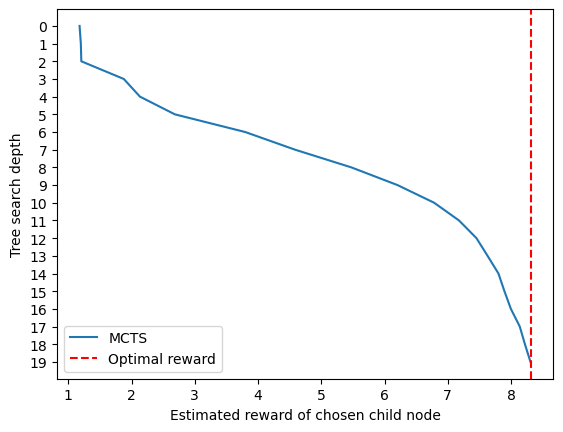

('00000011000010010111',
 {'MCiter': 50,
  'c_param': 5,
  'optimal_reward': 8.32264525748812,
  'final_reward': 8.307204357195934,
  'Efficiency': 0.0003328326538397349,
  'Reward_effectiveness': 0.9981447124304267,
  'Edit_distance': 0})

In [304]:
MCTS_binary_tree_search(PRINT=True, path=True)

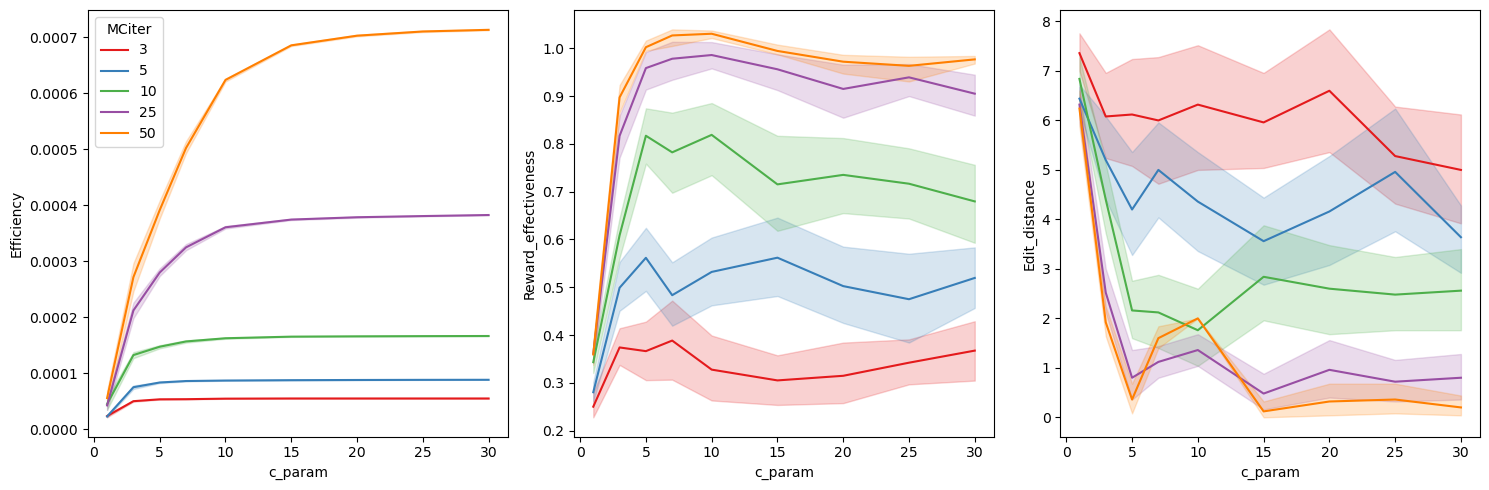

In [378]:
from pandas import DataFrame
import seaborn as sns

def MCTSexperiments(MCgrid = [3, 5, 10, 25, 50],
                    cgrid = [1, 3, 5, 7, 10, 15, 20, 25, 30],
                    restarts_per_setup:int = 10):
    results = []
    # Collect results
    for mc in MCgrid:
        for cp in cgrid:
            for _ in range(restarts_per_setup):
                _, res = MCTS_binary_tree_search(mc, cp)
                results.append(res)
    
    # Organize results
    ResDF = DataFrame(results)

    # Plot results
    f, ax = plt.subplots(ncols=3, figsize = (15, 5))

    sns.lineplot(ResDF,
                 x = 'c_param',
                 y = 'Efficiency',
                 hue = 'MCiter',
                 palette='Set1',
                 ax=ax[0])
    
    sns.lineplot(ResDF,
                 x = 'c_param',
                 y = 'Reward_effectiveness',
                 hue = 'MCiter',
                 palette='Set1',
                 legend=False,
                 ax=ax[1])
    
    sns.lineplot(ResDF,
                 x = 'c_param',
                 y = 'Edit_distance',
                 hue = 'MCiter',
                 palette='Set1',
                 legend=False,
                 ax=ax[2])
    
    f.tight_layout(); plt.show()

MCTSexperiments(restarts_per_setup=25)

### Markov Decision Process

- State space: 12 states (circular state space: clock); 12 is absorbing (s=0/s=12)
- Action space: clockwise (0|R) / counterclockwise (1|L)
- Transition prob: 5-11 deterministic transitions; 1-4 stochastic p = 1-eps intended action, and p = eps opposite action
- Rewards: transition to Non-absorbing: rNT = -1; transition to absorbing: rT = +10
- Discount factor: 1 (undiscounted)

Transition probability matrix (action CLOCKWISE (right))
[[0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.  ]
 [0.45 0.   0.55 0.   0.   0.   0.   0.   0.   0.   0.   0.  ]
 [0.   0.45 0.   0.55 0.   0.   0.   0.   0.   0.   0.   0.  ]
 [0.   0.   0.45 0.   0.55 0.   0.   0.   0.   0.   0.   0.  ]
 [0.   0.   0.   0.45 0.   0.55 0.   0.   0.   0.   0.   0.  ]
 [0.   0.   0.   0.   0.   0.   1.   0.   0.   0.   0.   0.  ]
 [0.   0.   0.   0.   0.   0.   0.   1.   0.   0.   0.   0.  ]
 [0.   0.   0.   0.   0.   0.   0.   0.   1.   0.   0.   0.  ]
 [0.   0.   0.   0.   0.   0.   0.   0.   0.   1.   0.   0.  ]
 [0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   1.   0.  ]
 [0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   1.  ]
 [1.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.  ]]
Transition probability matrix (action COUNTER-CLOCKWISE (left))
[[0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.  ]
 [0.55 0.   0.45 0.   0.   0.   0.   0.   0.   0.   0.   0.

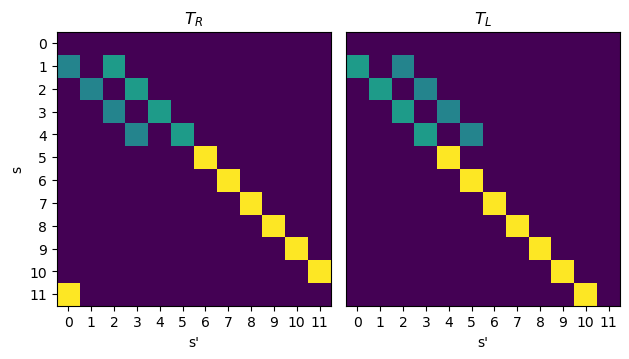

In [279]:
def makeTransProb(eps:float):
    ''' 
    Rows FROM, Cols TO
    '''
    assert 0 <= eps < 0.5

    # Right: clockwise
    Ropp = np.diag(np.full(4, eps), -1)
    Tright = np.eye(N = 12, k = 1)
    Tright[0,:] = 0
    Tright[:5, :] *= (1-eps)
    Tright[:5, :5] += Ropp
    Tright[-1, 0] = 1

    # Left: counterclockwise
    Lopp = np.diag(np.full(4, eps), 1)
    Tleft = np.eye(N = 12, k = -1)
    Tleft[:5, :] *= (1-eps)
    Tleft[1:6, 1:6] += Lopp
    
    return Tright, Tleft

tr, tl = makeTransProb(0.45)
print('Transition probability matrix (action CLOCKWISE (right))')
print(tr)
print('Transition probability matrix (action COUNTER-CLOCKWISE (left))')
print(tl)

f, ax = plt.subplots(ncols=2)
ax[0].imshow(tr)
ax[0].set_xticks(np.arange(tl.shape[0]))
ax[0].set_yticks(np.arange(tl.shape[0]))
ax[0].set_ylabel('s')
ax[0].set_xlabel("s'")
ax[0].set_title(r'$T_R$')
ax[1].imshow(tl)
ax[1].set_xticks(np.arange(tl.shape[0]))
ax[1].set_xlabel("s'")
ax[1].get_yaxis().set_visible(False)
ax[1].set_title(r'$T_L$')
f.tight_layout(); plt.show()

Expected immediate reward r_{s,a}:
[[ 0.    0.  ]
 [-0.55  5.5 ]
 [-0.55 -0.55]
 [-0.55 -0.55]
 [-0.55 -0.55]
 [-1.   -1.  ]
 [-1.   -1.  ]
 [-1.   -1.  ]
 [-1.   -1.  ]
 [-1.   -1.  ]
 [-1.   -1.  ]
 [10.   -1.  ]]


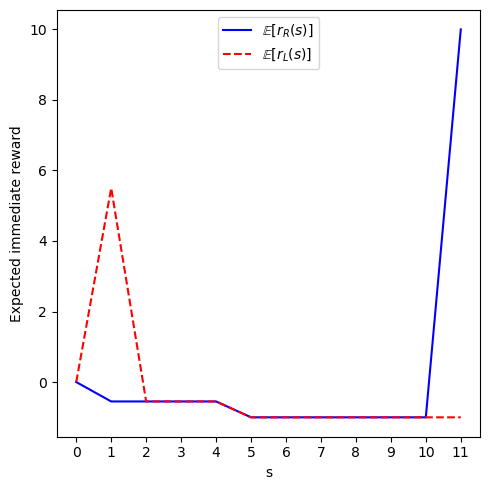

In [374]:
def makeImmediateReward(NT:float = -1, T:float = 10):
    # 0: right clockwise
    rR = np.eye(12, k=1) * NT
    rR[0,:] = 0
    rR[-1, 0] = T # 11->12 transition
    # 1: left counterclockwise
    rL = np.eye(12, k=-1) * NT
    rL[1, 0] = T # 12<-1 transition
    return rR, rL
    
def makeExpectedReward(T:tuple[np.ndarray, np.ndarray],
                       r:tuple[np.ndarray, np.ndarray]
                       )-> np.ndarray:
    TR, TL = T
    RR, RL = r

    ErR = (TR * RR).sum(axis = 1)
    ErL = (TL * RL).sum(axis = 1) 

    Er = np.column_stack((ErR, ErL))
    return Er

print('Expected immediate reward r_{s,a}:')
er = makeExpectedReward(makeTransProb(eps=0.45), makeImmediateReward())
print(er)
f, ax = plt.subplots(figsize = (5,5))
ax.plot(er[:, 0], color = 'blue', label = r'$\mathbb{E}[r_R(s)]$')
ax.plot(er[:, 1], color = 'red', linestyle = '--', label = r'$\mathbb{E}[r_L(s)]$')
ax.set_xticks(np.arange(er.shape[0]))
# ax.set_title(r'$\mathbb{E}[r_a(s)]$')
ax.set_xlabel('s'); ax.set_ylabel('Expected immediate reward')
ax.legend(loc = 9)
f.tight_layout(); plt.show()

$v^* = \max_a (r_a + T_a v^*)$

can solve via value iteration
while $\max\{v^{t} - v^{t-1}\} \ge \Delta$

In [250]:
def find_policy(eps:float, delta:float = 1e-5,
                NT:float = -1, T:float = 10,
                PRINT:bool = True):
    TR, TL = makeTransProb(eps)
    TProb = np.dstack((TR, TL)).transpose((2, 0, 1))
    ER = makeExpectedReward((TR, TL), makeImmediateReward(NT, T))
    vstar = value_iteration(ER, TProb, delta)
    policy = policy_from_value(vstar, ER)
    if PRINT:
        print(f'Value iteration for MDP with epsilon = {eps}')
        print(f'V Star:\n {vstar}')
        print(f'π Star:\n {policy}')
    return vstar, policy

def value_iteration(ER:np.ndarray, TProb:np.ndarray,
                    delta:float = 1e-5,
                    )->np.ndarray:
    # Start value iteration with expected reward
    v0 = ER.mean(axis = 1)
    delta_t = 1e3
    # Value iteration until ∆ small enough
    while delta_t >= delta:
        v1 = np.max(ER + (TProb @ v0).T,
                    axis = 1)
        delta_t = max(v1 - v0)
        v0 = v1
    return v1

def policy_from_value(vstar:np.ndarray, er:np.ndarray)->np.ndarray:
    policy = np.zeros((len(vstar)-1, 2))
    values = np.zeros_like(policy)
    
    # Clockwise move
    values[:,0] = np.roll(vstar, -1)[1:]
    # Counterclockwise move
    values[:,1] = np.roll(vstar, 1)[1:]
    # Add immediate rewards
    values += er[1:, :]
    # Best moves
    best = np.argmax(values, axis = 1)
    # Ties
    ties = (values[:, 0] == values[:, 1])
    # Policy
    policy[np.arange(len(best)), best] = 1
    policy[ties,:] = 1/2
    return policy

In [252]:
# Q2
v2, pi2 = find_policy(eps=0)

Value iteration for MDP with epsilon = 0
V Star:
 [ 0. 10.  9.  8.  7.  6.  5.  6.  7.  8.  9. 10.]
π Star:
 [[0.  1. ]
 [0.  1. ]
 [0.  1. ]
 [0.  1. ]
 [0.  1. ]
 [0.5 0.5]
 [1.  0. ]
 [1.  0. ]
 [1.  0. ]
 [1.  0. ]
 [1.  0. ]]


In [254]:
# Q3a
v3a, pi3a = find_policy(eps=0.2)

Value iteration for MDP with epsilon = 0.2
V Star:
 [ 0.          9.66796811  8.33984178  7.02733827  5.77733484  4.77732919
  5.          6.          7.          8.          9.         10.        ]
π Star:
 [[0. 1.]
 [0. 1.]
 [0. 1.]
 [0. 1.]
 [0. 1.]
 [1. 0.]
 [1. 0.]
 [1. 0.]
 [1. 0.]
 [1. 0.]
 [1. 0.]]


In [255]:
# Q3b
v3b, pi3b = find_policy(eps=0.45)

Value iteration for MDP with epsilon = 0.45
V Star:
 [ 0.          8.13720191  5.86045611  4.2999918   3.61499454  4.
  5.          6.          7.          8.          9.         10.        ]
π Star:
 [[0. 1.]
 [0. 1.]
 [0. 1.]
 [0. 1.]
 [1. 0.]
 [1. 0.]
 [1. 0.]
 [1. 0.]
 [1. 0.]
 [1. 0.]
 [1. 0.]]


In [383]:
# bonus
v3bonus, pi3bonus = find_policy(eps=0.49)

Value iteration for MDP with epsilon = 0.49
V Star:
 [ 0.          7.71209494  5.33080776  3.89315507  3.43764191  4.
  5.          6.          7.          8.          9.         10.        ]
π Star:
 [[0. 1.]
 [0. 1.]
 [0. 1.]
 [1. 0.]
 [1. 0.]
 [1. 0.]
 [1. 0.]
 [1. 0.]
 [1. 0.]
 [1. 0.]
 [1. 0.]]


In [346]:
# Question 4: Parametrized policy
def param_policy(state:int, theta:float)->float:
    '''
    Policy parametrizing p(a = R | s = state)
    '''
    sigmoid = lambda x: 1 / (1 + np.exp(-x))
    return sigmoid(state-theta)

def policy_rollout(theta:float, eps:float,
                   nt:float = -1, t:float = 10
                   )->float:
    # transition probabilities
    Transition:tuple[np.ndarray] = makeTransProb(eps)
    # expected immediate rewards
    Reward:tuple[np.ndarray] = makeImmediateReward(nt, t)
    starting_states = np.arange(1, 12)
    successor_states = np.arange(12) # incl. terminal
    # action probabilities (in each state)
    pR = param_policy(starting_states, theta)
    pL = 1 - pR
    prob_a = np.column_stack((pR, pL))
    # rollout
    state = np.random.choice(starting_states)
    cumulative_reward = 0
    while state != 0:
        # choose action according to policy
        action = np.random.choice([0,1], p = prob_a[state-1])
        T = Transition[action]
        R = Reward[action]
        # successor according to transition probability
        successor = np.random.choice(successor_states, p = T[state])
        # assign immediate reward
        cumulative_reward += R[state, successor]
        # continue rollout
        state = successor
    return cumulative_reward

def fit_param_policy_MC(theta_grid:np.ndarray, eps:float,
                        nrollouts:int = 10,
                        nt:float = -1, t:float = 10):
    theta_rewards = np.zeros_like(theta_grid)
    
    # Obtain MC estimates of the various theta params
    for itheta, theta in enumerate(theta_grid):
        for _ in range(nrollouts):
            theta_rewards[itheta] += policy_rollout(theta, eps, nt, t)
    
    # Choose theta param with the highest expected return
    theta_rewards /= nrollouts
    theta_star_idx = np.argmax(theta_rewards)
    theta_star = theta_grid[theta_star_idx]

    return theta_star, theta_rewards

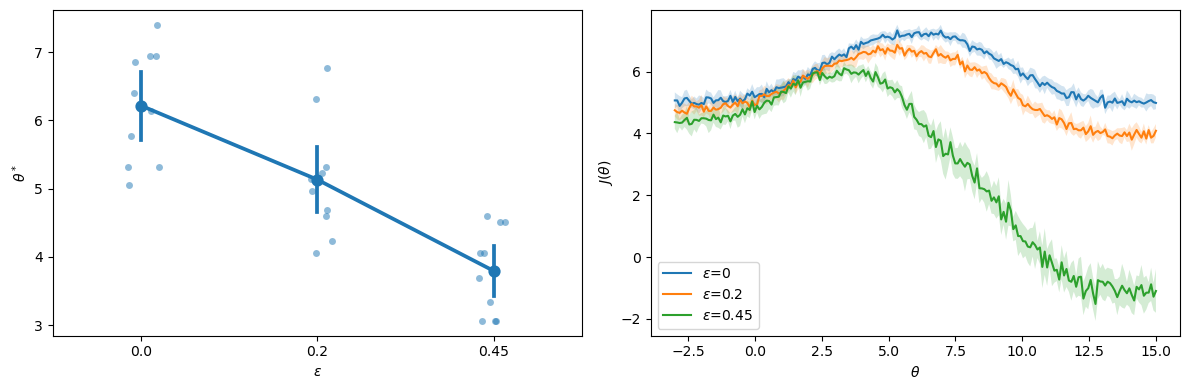

In [373]:
from joblib import Parallel, delayed

def MDPexperiments(theta_grid: np.ndarray, eps_grid: np.ndarray,
                   nrollouts: int, reruns: int,
                   nt: float = -1, t: float = 10,
                   n_jobs: int = -1):

    rows = []
    curves = {}  # eps -> (mean_curve, std_curve)

    # Collect data from different runs
    for eps in eps_grid:
        res = Parallel(n_jobs=n_jobs)(
            delayed(fit_param_policy_MC)(theta_grid, eps, nrollouts, nt, t)
            for _ in range(reruns)
        )

        thetas = np.array([r[0] for r in res], dtype=float)
        Jcurves = np.stack([r[1] for r in res], axis=0)  # (reruns, |theta_grid|)

        # store per-run summary
        for i, th in enumerate(thetas):
            rows.append({"eps": float(eps), "theta_star": float(th), "J_star": float(max(Jcurves[i,:]))})

        # store mean/std curves for plotting
        curves[float(eps)] = (Jcurves.mean(axis=0), Jcurves.std(axis=0))

    df = DataFrame(rows)

    # Plot 1: theta* vs eps
    f, ax = plt.subplots(ncols=2, figsize=(12, 4))

    sns.stripplot(data=df, x="eps", y="theta_star", ax=ax[0], alpha=0.5)
    sns.pointplot(data=df, x="eps", y="theta_star", ax=ax[0], errorbar="ci")
    ax[0].set_xlabel(r'$\epsilon$')
    ax[0].set_ylabel(r'$\theta^*$')

    # Plot 2: mean J(theta) curves for each eps
    for eps in eps_grid:
        eps = float(eps)
        mean_curve, std_curve = curves[eps]
        ax[1].plot(theta_grid, mean_curve, label=fr'$\epsilon$={eps:g}')
        ax[1].fill_between(theta_grid, mean_curve - std_curve, mean_curve + std_curve, alpha=0.2)

    ax[1].set_xlabel(r'$\theta$')
    ax[1].set_ylabel(r'$J(\theta)$')
    ax[1].legend(loc=3)
    f.tight_layout(); plt.show()
    return df, curves

df, curves = MDPexperiments(
    theta_grid=np.linspace(-3, 15, 200),
    eps_grid=np.array([0.0, 0.2, 0.45]),
    nrollouts=200,
    reruns=10
)

# 🎉 !HAPPY NEW YEAR! 🥳